lets import all the libraries !


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import regressor as rg



In [2]:
df = pd.read_csv("../Data/Admission_Predict_Ver1.1.csv")
df.columns = df.columns.str.strip()
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Took three features from the dataset to visualize its behavior

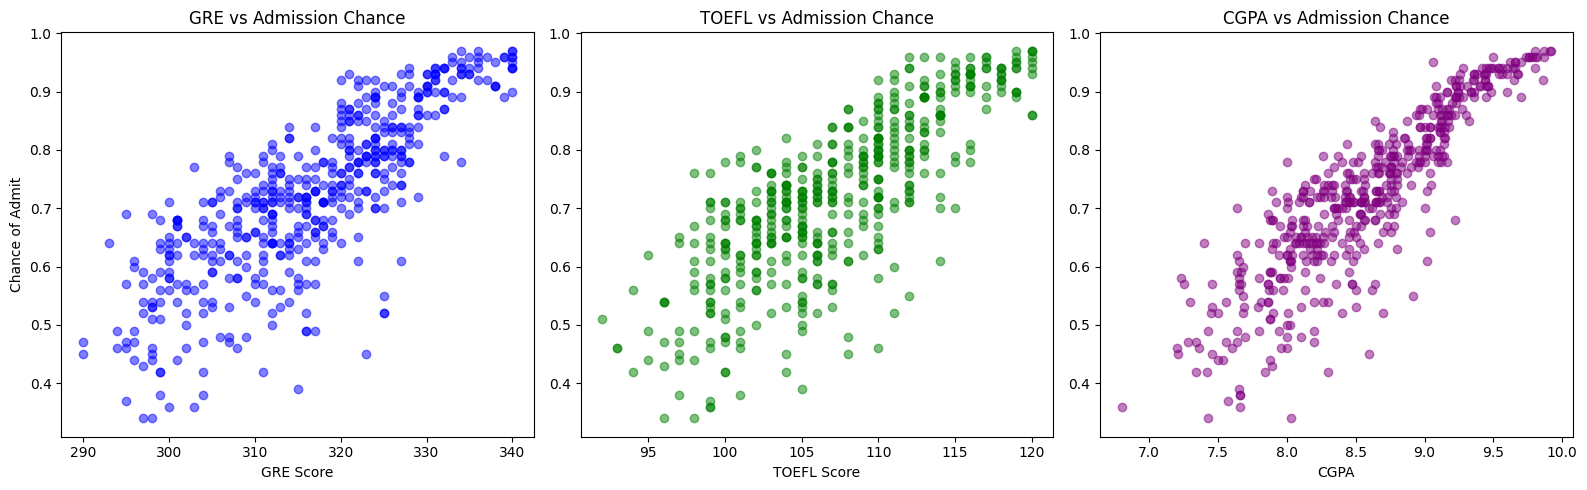

In [ ]:



df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['GRE Score'], df['Chance of Admit'], color='blue', alpha=0.5)
axes[0].set_xlabel('GRE Score')
axes[0].set_ylabel('Chance of Admit')
axes[0].set_title('GRE vs Admission Chance')

axes[1].scatter(df['TOEFL Score'], df['Chance of Admit'], color='green', alpha=0.5)
axes[1].set_xlabel('TOEFL Score')
axes[1].set_title('TOEFL vs Admission Chance')


axes[2].scatter(df['CGPA'], df['Chance of Admit'], color='purple', alpha=0.5)
axes[2].set_xlabel('CGPA')
axes[2].set_title('CGPA vs Admission Chance')


plt.tight_layout()

plt.show()

Correlation Heatmap 

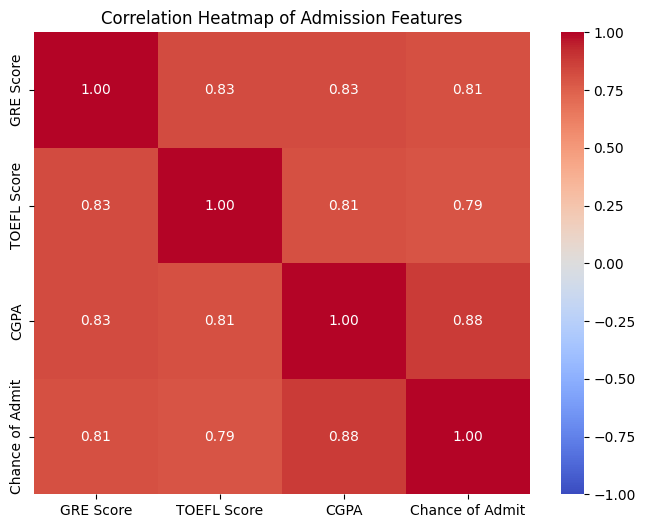

In [ ]:

import seaborn as sns

numerical_df = df[['GRE Score', 'TOEFL Score', 'CGPA', 'Chance of Admit']]
corr_matrix = numerical_df.corr()

# 4. Draw the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title("Correlation Heatmap of Admission Features")
plt.show()

Lets analyze the data after applying the z-score Normalization. We can see now how the numbers are confined to a specific range of numbers.

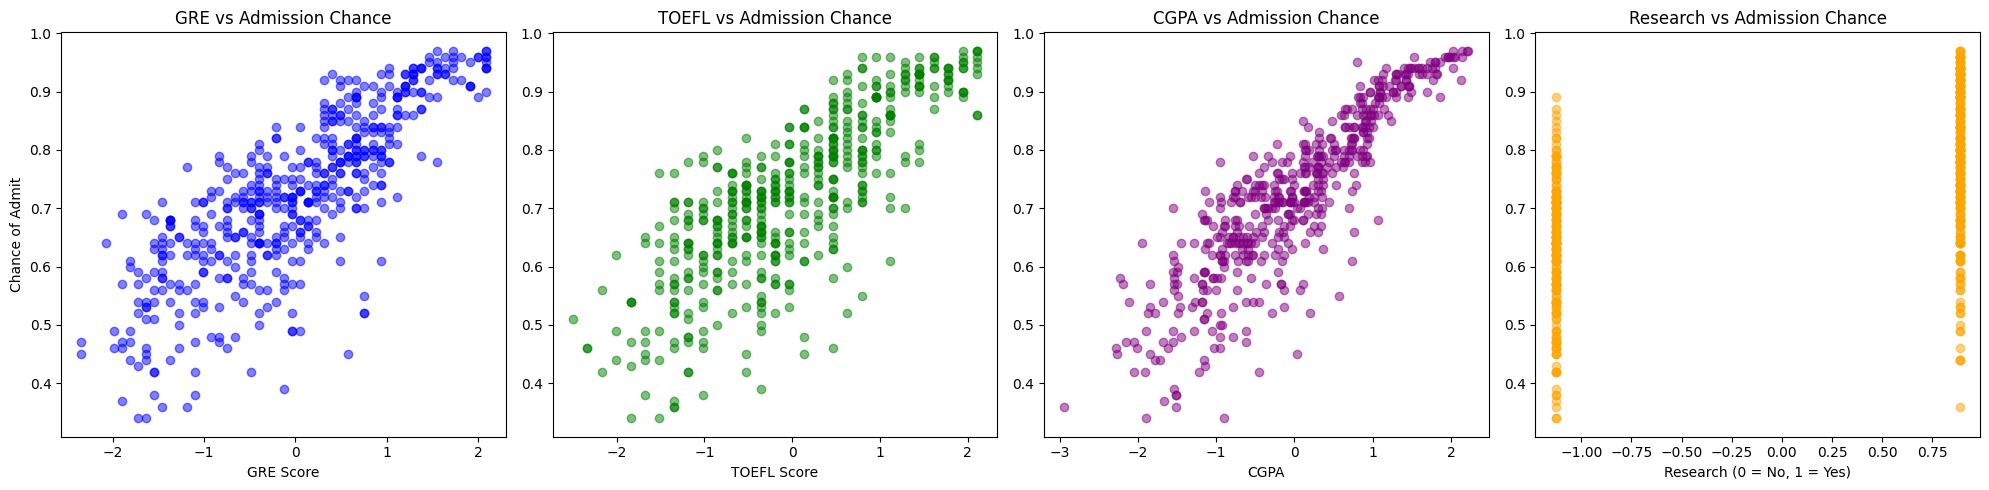

In [ ]:
x_train = df[['GRE Score', 'TOEFL Score', 'CGPA', 'Research']].to_numpy()
y_train = df['Chance of Admit']

x_train,mu,sig = rg.z_normalize(x_train)
np.array(x_train)

#
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].scatter(x_train[:, 0], y_train, color='blue', alpha=0.5)
axes[0].set_xlabel('GRE Score')
axes[0].set_ylabel('Chance of Admit')
axes[0].set_title('GRE vs Admission Chance')


axes[1].scatter(x_train[:, 1], y_train, color='green', alpha=0.5)
axes[1].set_xlabel('TOEFL Score')
axes[1].set_title('TOEFL vs Admission Chance')


axes[2].scatter(x_train[:, 2], y_train, color='purple', alpha=0.5)
axes[2].set_xlabel('CGPA')
axes[2].set_title('CGPA vs Admission Chance')

axes[3].scatter(x_train[:, 3], y_train, color='orange', alpha=0.5)
axes[3].set_xlabel('Research (0 = No, 1 = Yes)')
axes[3].set_title('Research vs Admission Chance')

# Clean up layout spacing
plt.tight_layout()

# Show the plots
plt.show()

Lets Analyze the fit, how good the model fits to the data? From the plot we can say that the model decently fits to the data. On the other side we can see the Cost v Iteration plot as well indicating not much change in the cost after roughly 500 iterations 

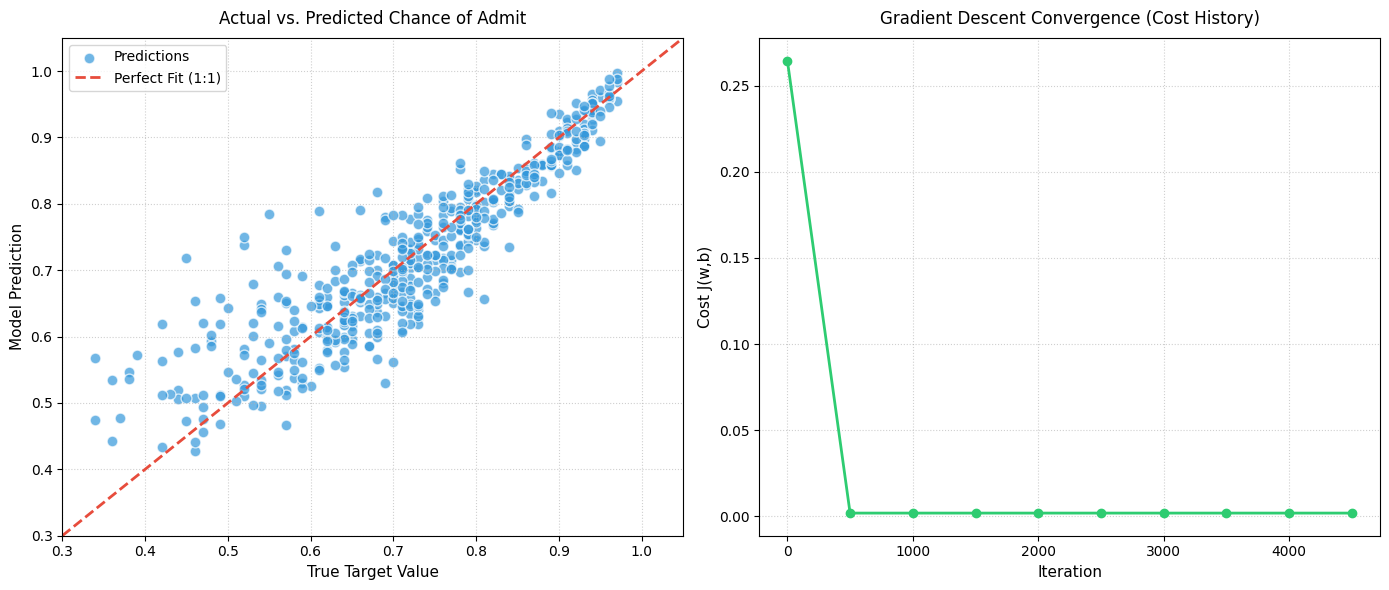

In [7]:



from regressor import load_data, z_normalize, load_model

x_train, y_train = load_data('../Data/Admission_Predict_Ver1.1.csv')
x_train, mu, sigma = z_normalize(x_train)
w_final, b_final, mu, sigma = load_model(prefix='admission_model')

predict_tracker = []
m, _ = x_train.shape
for i in range(m):
    predict = np.dot(x_train[i], w_final) + b_final
    predict_tracker.append(predict)

y_true = y_train
y_pred = predict_tracker

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(y_true, y_pred, color="#3498db", alpha=0.7, edgecolors="w", s=60, label="Predictions")

perfect_line = np.linspace(0.3, 1.05, 100)
ax1.plot(perfect_line, perfect_line, color="#e74c3c", linestyle="--", linewidth=2, label="Perfect Fit (1:1)")

ax1.set_title("Actual vs. Predicted Chance of Admit", fontsize=12, pad=10)
ax1.set_xlabel("True Target Value", fontsize=11)
ax1.set_ylabel("Model Prediction", fontsize=11)
ax1.set_xlim(0.3, 1.05)
ax1.set_ylim(0.3, 1.05)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

iterations = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]
costs = [0.2646, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019]

ax2.plot(iterations, costs, color="#2ecc71", marker="o", linewidth=2, markersize=6)
ax2.set_title("Gradient Descent Convergence (Cost History)", fontsize=12, pad=10)
ax2.set_xlabel("Iteration", fontsize=11)
ax2.set_ylabel("Cost J(w,b)", fontsize=11)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()